In [ ]:
# ==========================
# 1. IMPORT LIBRARIES
# ==========================
import zipfile
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================
# 2. EXTRACT ZIP FILE
# ==========================
zip_path = "/content/archive (21).zip"
extract_path = "/content/brain_tumor_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root)
    print("Number of files:", len(files))
    print("-"*50)

/content/brain_tumor_dataset
Number of files: 0
--------------------------------------------------
/content/brain_tumor_dataset/no
Number of files: 98
--------------------------------------------------
/content/brain_tumor_dataset/yes
Number of files: 155
--------------------------------------------------
/content/brain_tumor_dataset/brain_tumor_dataset
Number of files: 0
--------------------------------------------------
/content/brain_tumor_dataset/brain_tumor_dataset/no
Number of files: 98
--------------------------------------------------
/content/brain_tumor_dataset/brain_tumor_dataset/yes
Number of files: 155
--------------------------------------------------


In [ ]:
# ==========================
# LOAD IMAGES
# ==========================

import os
import cv2
import numpy as np

IMG_SIZE = 128

data = []
labels = []

yes_folder = None
no_folder = None

for root, dirs, files in os.walk(extract_path):

    if os.path.basename(root).lower() == "yes":
        yes_folder = root

    elif os.path.basename(root).lower() == "no":
        no_folder = root

print("YES folder:", yes_folder)
print("NO folder :", no_folder)

# Tumor = 1
for file in os.listdir(yes_folder):

    path = os.path.join(yes_folder, file)

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(1)

# No Tumor = 0
for file in os.listdir(no_folder):

    path = os.path.join(no_folder, file)

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(0)

print("Total Images:", len(data))
print("Tumor Images:", labels.count(1))
print("No Tumor Images:", labels.count(0))

YES folder: /content/brain_tumor_dataset/brain_tumor_dataset/yes
NO folder : /content/brain_tumor_dataset/brain_tumor_dataset/no
Total Images: 253
Tumor Images: 155
No Tumor Images: 98


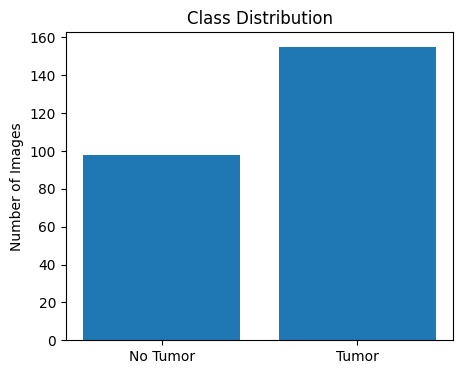

In [ ]:
import matplotlib.pyplot as plt

tumor_count = labels.count(1)
no_count = labels.count(0)

plt.figure(figsize=(5,4))
plt.bar(["No Tumor","Tumor"], [no_count,tumor_count])
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

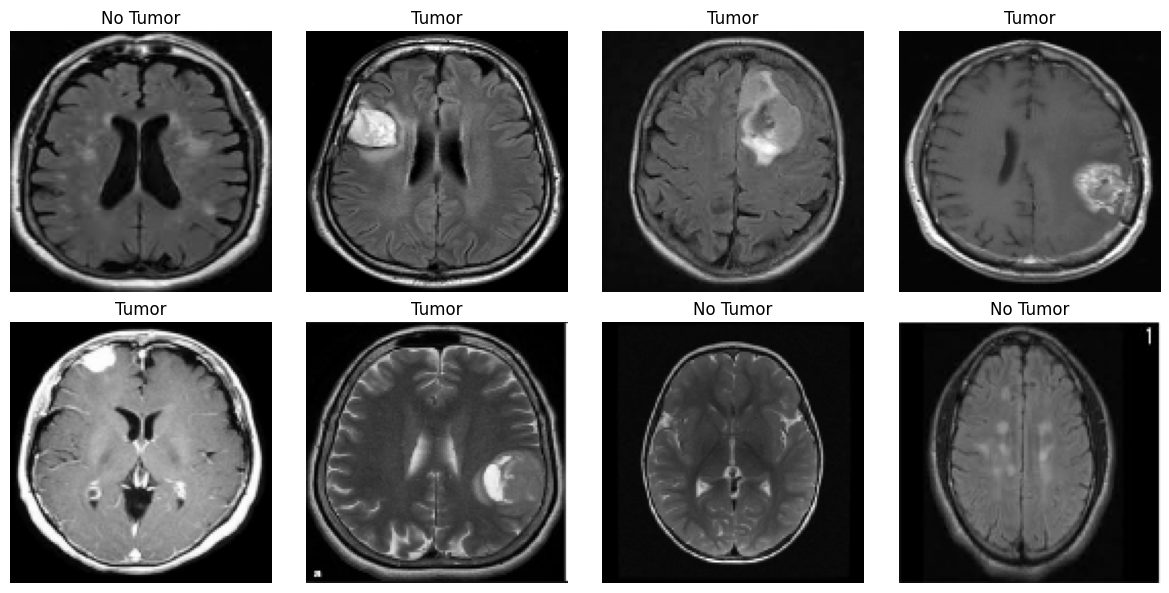

In [ ]:
plt.figure(figsize=(12,6))

for i in range(8):

    idx = np.random.randint(len(data))

    plt.subplot(2,4,i+1)
    plt.imshow(data[idx], cmap="gray")

    title = "Tumor" if labels[idx]==1 else "No Tumor"
    plt.title(title)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X = np.array(data)

# Normalize
X = X / 255.0

# Flatten images
X = X.reshape(len(X), -1)

y = np.array(labels)

print(X.shape)
print(y.shape)

(253, 16384)
(253,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (202, 16384)
Test : (51, 16384)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

Accuracy: 76.47%

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        20
           1       0.81      0.81      0.81        31

    accuracy                           0.76        51
   macro avg       0.75      0.75      0.75        51
weighted avg       0.76      0.76      0.76        51


Confusion Matrix:
[[14  6]
 [ 6 25]]


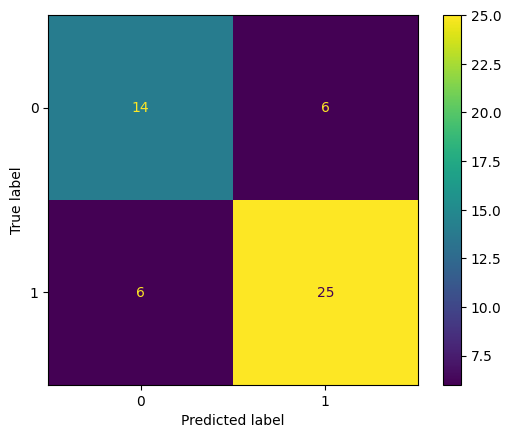

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [ ]:
X.shape

(253, 16384)

/content/brain_tumor_dataset/brain_tumor_dataset/yes/Y28.jpg


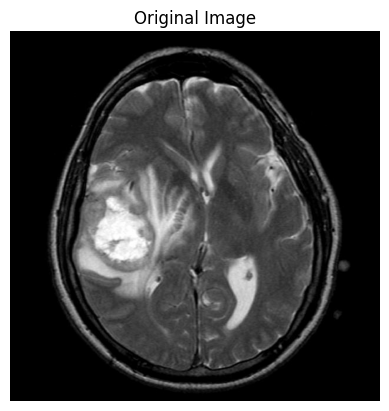

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
import os

# Select random image from tumor folder
file = random.choice(os.listdir(yes_folder))

image_path = os.path.join(yes_folder, file)


print(image_path)

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()


In [ ]:
img2 = cv2.resize(img, (128,128))
img2 = img2 / 255.0
img2 = img2.reshape(1,-1)

pred = rf.predict(img2)[0]

print("Prediction:",
      "Brain Tumor" if pred==1 else "No Brain Tumor")

Prediction: Brain Tumor


Saving images.jpg to images.jpg


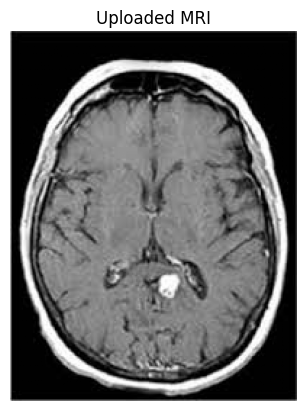

🧠 Prediction: Brain Tumor Detected
No Tumor Probability : 32.00%
Tumor Probability    : 68.00%


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Show image
plt.imshow(img, cmap='gray')
plt.title("Uploaded MRI")
plt.axis('off')
plt.show()

# Preprocess (same as training)
img_processed = cv2.resize(img, (128, 128))
img_processed = img_processed / 255.0
img_processed = img_processed.reshape(1, -1)

# Predict
prediction = rf.predict(img_processed)[0]
probabilities = rf.predict_proba(img_processed)[0]

# Output
if prediction == 1:
    print("🧠 Prediction: Brain Tumor Detected")
else:
    print("✅ Prediction: No Brain Tumor")

print(f"No Tumor Probability : {probabilities[0]*100:.2f}%")
print(f"Tumor Probability    : {probabilities[1]*100:.2f}%")